In [8]:
!pip install -q piq scikit-image opencv-python-headless timm albumentations

import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Count:       {torch.cuda.device_count()}")
    print(f"GPU Device 0:    {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 2.6 MB/s eta 0:00:00a 0:00:01
PyTorch Version: 2.10.0+cu128
CUDA Available:  True
GPU Count:       2
GPU Device 0:    Tesla T4


In [9]:
import os
import gc
import cv2
import time
import glob
import math
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import piq
from skimage.metrics import structural_similarity as compute_skimage_ssim

warnings.filterwarnings('ignore')

class Config:
    SEED = 42
    NUM_GPUS = torch.cuda.device_count()
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = os.cpu_count() or 4

    # Auto-detect dataset directory across various Kaggle and local paths
    CANDIDATES = [
        '/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset',
        '/kaggle/input/covid-19-radiography-database/COVID-19_Radiography_Dataset',
        '/kaggle/input/covid19-radiography-database',
        '/kaggle/input/covid-19-radiography-database',
        '/kaggle/input',
        './data/dataset1_covid_radiography',
        '.'
    ]

    INPUT_DATASET_DIR = None
    for cand in CANDIDATES:
        if os.path.exists(cand):
            # Check if there are image files inside
            for root, _, files in os.walk(cand):
                if any(f.lower().endswith(('.png', '.jpg', '.jpeg')) and 'mask' not in f.lower() for f in files):
                    INPUT_DATASET_DIR = cand
                    break
            if INPUT_DATASET_DIR:
                break

    if INPUT_DATASET_DIR is None:
        INPUT_DATASET_DIR = '/kaggle/input'

    WORKING_DIR = '/kaggle/working/qaap_pipeline'
    OUTPUT_PREPROCESSED_DIR = os.path.join(WORKING_DIR, 'qaap_processed_images')
    LOGS_DIR = os.path.join(WORKING_DIR, 'logs')
    METRICS_DIR = os.path.join(WORKING_DIR, 'metrics')

    TARGET_SIZE = (224, 224)
    BATCH_SIZE_IQA = 256 if NUM_GPUS > 1 else 128

    BIN_LABELS = ['Very Poor', 'Poor', 'Medium', 'Good', 'Excellent']
    NUM_BINS = 5

for d in [Config.WORKING_DIR, Config.OUTPUT_PREPROCESSED_DIR, Config.LOGS_DIR, Config.METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"[INIT] Device: {Config.DEVICE} ({Config.NUM_GPUS} GPUs) | CPU Workers: {Config.NUM_WORKERS}")
print(f"[INIT] Detected Dataset Path: {Config.INPUT_DATASET_DIR}")
if os.path.exists('/kaggle/input'):
    print(f"[INIT] Available in /kaggle/input: {os.listdir('/kaggle/input')}")

[INIT] Device: cuda (2 GPUs) | CPU Workers: 4
[INIT] Detected Dataset Path: /kaggle/input
[INIT] Available in /kaggle/input: ['notebooks', 'datasets']


In [10]:
def discover_cxr_images(dataset_root):
    valid_exts = {'.png', '.jpg', '.jpeg'}
    image_records = []

    print(f"[SCAN] Searching for CXR images in: {dataset_root}")
    for root, _, files in os.walk(dataset_root):
        # Exclude mask folders
        if 'mask' in root.lower():
            continue
        for f in files:
            # Exclude mask files
            if 'mask' in f.lower():
                continue
            ext = os.path.splitext(f)[1].lower()
            if ext in valid_exts:
                full_path = os.path.join(root, f)
                parent_dir = os.path.basename(root)
                grandparent_dir = os.path.basename(os.path.dirname(root))

                # Determine class label (COVID, Normal, Lung_Opacity, Viral Pneumonia, etc.)
                if parent_dir.lower() in ['images', 'imgs']:
                    class_label = grandparent_dir
                else:
                    class_label = parent_dir

                image_records.append({
                    'file_path': full_path,
                    'file_name': f,
                    'class': class_label
                })

    # Explicit column initialization prevents KeyError even if image_records is empty
    df = pd.DataFrame(image_records, columns=['file_path', 'file_name', 'class'])

    if len(df) == 0:
        print(f"[ERROR] No images found under '{dataset_root}'!")
        print(f"[DIAGNOSTIC] Listing contents of /kaggle/input:")
        if os.path.exists('/kaggle/input'):
            for item in os.listdir('/kaggle/input'):
                print(f"  - /kaggle/input/{item}")
        print("\nPlease ensure you added the dataset via '+ Add Data' in Kaggle.")
        return df

    print(f"[DATASET] Discovered {len(df)} CXR images across classes: {df['class'].unique().tolist()}")
    return df


class CXRQualityDataset(Dataset):
    def __init__(self, file_paths, target_size=(224, 224)):
        self.file_paths = file_paths
        self.target_size = target_size

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros(self.target_size, dtype=np.uint8)
        else:
            if img.shape[:2] != self.target_size:
                img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_AREA)
        tensor_img = torch.from_numpy(img).float().unsqueeze(0) / 255.0
        return tensor_img, path


class CXRQualityEvaluator:
    def __init__(self, device=Config.DEVICE, batch_size=Config.BATCH_SIZE_IQA):
        self.device = device
        self.batch_size = batch_size
        self.bin_edges = None
        self.bin_labels = Config.BIN_LABELS

    def compute_dataset_quality(self, file_paths):
        dataset = CXRQualityDataset(file_paths, target_size=Config.TARGET_SIZE)
        loader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=Config.NUM_WORKERS,
            pin_memory=True if self.device.type == 'cuda' else False,
            drop_last=False
        )

        all_paths, raw_brisque_scores = [], []
        start_time = time.time()

        with torch.no_grad():
            for batch_imgs, batch_paths in tqdm(loader, desc="GPU BRISQUE Extraction"):
                batch_imgs = batch_imgs.to(self.device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):
                    try:
                        scores = piq.brisque(batch_imgs, reduction='none', data_range=1.0)
                        scores_list = scores.detach().cpu().numpy().flatten().tolist()
                    except Exception:
                        scores_list = [50.0] * batch_imgs.size(0)

                raw_brisque_scores.extend(scores_list)
                all_paths.extend(batch_paths)

        elapsed = time.time() - start_time
        print(f"[IQA] Completed in {elapsed:.2f}s ({len(file_paths)/max(elapsed, 1e-3):.1f} img/sec)")

        raw_scores_arr = np.nan_to_num(np.array(raw_brisque_scores, dtype=np.float32), nan=50.0)
        quality_indices = np.clip(100.0 - raw_scores_arr, 0.0, 100.0)

        return pd.DataFrame({
            'file_path': all_paths,
            'raw_brisque': raw_scores_arr,
            'quality_score': quality_indices
        })

    def fit_and_assign_bins(self, df_scores):
        quantiles = [0.20, 0.40, 0.60, 0.80]
        self.bin_edges = np.quantile(df_scores['quality_score'], quantiles).tolist()

        print("\n[BINNING] Empirical Quantile Cutoffs:")
        print(f"  Tier 0 (Very Poor) : [  0.00 -> {self.bin_edges[0]:.2f} ]")
        print(f"  Tier 1 (Poor)      : [ {self.bin_edges[0]:.2f} -> {self.bin_edges[1]:.2f} ]")
        print(f"  Tier 2 (Medium)    : [ {self.bin_edges[1]:.2f} -> {self.bin_edges[2]:.2f} ]")
        print(f"  Tier 3 (Good)      : [ {self.bin_edges[2]:.2f} -> {self.bin_edges[3]:.2f} ]")
        print(f"  Tier 4 (Excellent) : [ {self.bin_edges[3]:.2f} -> 100.00 ]")

        def _map_bin(score):
            if score <= self.bin_edges[0]: return 0, self.bin_labels[0]
            elif score <= self.bin_edges[1]: return 1, self.bin_labels[1]
            elif score <= self.bin_edges[2]: return 2, self.bin_labels[2]
            elif score <= self.bin_edges[3]: return 3, self.bin_labels[3]
            else: return 4, self.bin_labels[4]

        res = df_scores['quality_score'].apply(_map_bin)
        df_scores['bin_id'] = [r[0] for r in res]
        df_scores['bin_label'] = [r[1] for r in res]
        return df_scores

In [11]:
class AdaptiveImageProcessor:
    @staticmethod
    def apply_pipeline(img_gray, clip_limit=2.0, denoise_h=4, sharpen=False):
        if img_gray.dtype != np.uint8:
            img_gray = np.clip(img_gray, 0, 255).astype(np.uint8)

        # 1. Contrast Equalization (CLAHE)
        if clip_limit > 0.0:
            clahe = cv2.createCLAHE(clipLimit=float(clip_limit), tileGridSize=(8, 8))
            enhanced = clahe.apply(img_gray)
        else:
            enhanced = img_gray

        # 2. Optimized NLM Noise Filtering
        if denoise_h > 0:
            denoised = cv2.fastNlMeansDenoising(
                enhanced, None, h=int(denoise_h), templateWindowSize=5, searchWindowSize=13
            )
        else:
            denoised = enhanced

        # 3. Structural Margin Sharpening
        if sharpen:
            blurred = cv2.GaussianBlur(denoised, (0, 0), sigmaX=1.5)
            sharpened = cv2.addWeighted(denoised, 1.4, blurred, -0.4, 0)
            return np.clip(sharpened, 0, 255).astype(np.uint8)

        return denoised


class QAAPOptimizer:
    def __init__(self):
        self.search_space = {
            'clip_limit': [1.0, 2.0, 3.0, 4.0],
            'denoise_h': [0, 4, 8, 12, 16],
            'sharpen': [False, True]
        }
        self.param_combinations = [
            {'clip_limit': c, 'denoise_h': d, 'sharpen': s}
            for c in self.search_space['clip_limit']
            for d in self.search_space['denoise_h']
            for s in self.search_space['sharpen']
        ]

    @staticmethod
    def _apply_synthetic_degradation(img, tier):
        degraded = img.astype(np.float32)
        # Contrast degradation
        contrast_factor = 0.5 + 0.1 * tier
        degraded = np.clip((degraded - 128.0) * contrast_factor + 128.0, 0, 255)
        # Quantum mottle noise
        noise_sigma = max(0.0, (4 - tier) * 6.0)
        if noise_sigma > 0:
            degraded = np.clip(degraded + np.random.normal(0, noise_sigma, degraded.shape), 0, 255)
        # Motion blur
        if tier <= 1:
            ksize = 5 if tier == 0 else 3
            degraded = cv2.GaussianBlur(degraded, (ksize, ksize), 0)
        return degraded.astype(np.uint8)

    def optimize_lookup_table(self, reference_paths):
        print("\n=======================================================")
        print(" OPTIMIZING PREPROCESSING PARAMETERS (SDR-SSIM)")
        print("=======================================================")

        ref_imgs = []
        for p in reference_paths[:30]:
            im = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if im is not None:
                ref_imgs.append(cv2.resize(im, Config.TARGET_SIZE))

        lookup_table = {}
        summary_records = []

        for tier in range(Config.NUM_BINS):
            bin_label = Config.BIN_LABELS[tier]
            best_score = -1.0
            best_params = self.param_combinations[0]

            val_pairs = [(ref, self._apply_synthetic_degradation(ref, tier)) for ref in ref_imgs]

            for params in self.param_combinations:
                ssim_list = []
                for clean_ref, degraded_in in val_pairs:
                    restored = AdaptiveImageProcessor.apply_pipeline(
                        degraded_in,
                        clip_limit=params['clip_limit'],
                        denoise_h=params['denoise_h'],
                        sharpen=params['sharpen']
                    )
                    score = compute_skimage_ssim(
                        restored, clean_ref, data_range=255, gaussian_weights=True, sigma=1.5
                    )
                    ssim_list.append(score)

                mean_ssim = float(np.mean(ssim_list))
                if mean_ssim > best_score:
                    best_score = mean_ssim
                    best_params = params

            lookup_table[tier] = {
                'bin_label': bin_label,
                'clip_limit': best_params['clip_limit'],
                'denoise_h': best_params['denoise_h'],
                'sharpen': best_params['sharpen'],
                'restoration_ssim': best_score
            }

            summary_records.append({
                'bin_id': tier,
                'bin_label': bin_label,
                'clip_limit': best_params['clip_limit'],
                'denoise_h': best_params['denoise_h'],
                'sharpen': best_params['sharpen'],
                'restoration_ssim': best_score
            })

            print(f"[OPTIMIZED] Tier {tier} ({bin_label:<9}): CLAHE={best_params['clip_limit']}, "
                  f"NLM_h={best_params['denoise_h']:<2}, Sharpen={str(best_params['sharpen']):<5} "
                  f"| SDR-SSIM: {best_score:.4f}")

        df_lut = pd.DataFrame(summary_records)
        df_lut.to_csv(os.path.join(Config.METRICS_DIR, 'qaap_optimal_lookup_table.csv'), index=False)
        return lookup_table, df_lut

In [12]:
def _worker_process_image(item):
    cv2.setNumThreads(0)
    in_p, out_p, clip_limit, denoise_h, sharpen = item
    try:
        img = cv2.imread(in_p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return False

        resized = cv2.resize(img, Config.TARGET_SIZE, interpolation=cv2.INTER_AREA)
        processed = AdaptiveImageProcessor.apply_pipeline(
            resized, clip_limit=clip_limit, denoise_h=denoise_h, sharpen=sharpen
        )
        rgb_out = cv2.cvtColor(processed, cv2.COLOR_GRAY2RGB)

        os.makedirs(os.path.dirname(out_p), exist_ok=True)
        cv2.imwrite(out_p, rgb_out)
        return True
    except Exception:
        return False


def execute_qaap_dataset_generation(df_annotated, lookup_table, output_root):
    print(f"\n[PIPELINE] Processing {len(df_annotated)} images to '{output_root}'...")

    tasks = []
    for _, row in df_annotated.iterrows():
        tier_params = lookup_table[row['bin_id']]
        out_path = os.path.join(output_root, row['class'], row['file_name'])
        tasks.append((
            row['file_path'],
            out_path,
            tier_params['clip_limit'],
            tier_params['denoise_h'],
            tier_params['sharpen']
        ))

    start_time = time.time()
    success = 0
    with ProcessPoolExecutor(max_workers=Config.NUM_WORKERS) as executor:
        for res in tqdm(executor.map(_worker_process_image, tasks, chunksize=64), total=len(tasks), desc="QAAP Generation"):
            if res:
                success += 1

    elapsed = time.time() - start_time
    print(f"[PIPELINE] Completed in {elapsed:.2f}s ({success}/{len(tasks)} images written | {len(tasks)/max(elapsed, 1e-3):.1f} img/sec)")

In [13]:
def generate_audit_visualizations(df_scores, lookup_table):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Histogram
    sns.histplot(df_scores['quality_score'], kde=True, ax=axes[0], color='#2b5c8f', bins=40)
    axes[0].set_title('Inverted BRISQUE Score Distribution ($Q \in [0, 100]$)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Quality Index $Q(I)$', fontsize=10)
    axes[0].set_ylabel('CXR Image Count', fontsize=10)

    # 2. Boxplot
    sns.boxplot(data=df_scores, x='class', y='quality_score', ax=axes[1], palette='Blues_r')
    axes[1].set_title('Quality Score Variance Across Pathology Classes', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Class Label', fontsize=10)
    axes[1].set_ylabel('Quality Index $Q(I)$', fontsize=10)
    plt.xticks(rotation=15)

    plt.tight_layout()
    plt.savefig(os.path.join(Config.METRICS_DIR, 'qaap_quality_audit.png'), dpi=300)
    plt.show()

 STARTING QAAP PIPELINE EXECUTION (PHASE 2)
[SCAN] Searching for CXR images in: /kaggle/input
[DATASET] Discovered 21165 CXR images across classes: ['Normal', 'Lung_Opacity', 'Viral Pneumonia', 'COVID']


GPU BRISQUE Extraction:   0%|          | 0/83 [00:00<?, ?it/s]

Downloading: "https://github.com/photosynthesis-team/piq/releases/download/v0.4.0/brisque_svm_weights.pt" to /root/.cache/torch/hub/checkpoints/brisque_svm_weights.pt



100%|██████████| 112k/112k [00:00<00:00, 6.01MB/s]


[IQA] Completed in 47.27s (447.7 img/sec)

[BINNING] Empirical Quantile Cutoffs:
  Tier 0 (Very Poor) : [  0.00 -> 62.22 ]
  Tier 1 (Poor)      : [ 62.22 -> 68.97 ]
  Tier 2 (Medium)    : [ 68.97 -> 75.03 ]
  Tier 3 (Good)      : [ 75.03 -> 82.28 ]
  Tier 4 (Excellent) : [ 82.28 -> 100.00 ]

 OPTIMIZING PREPROCESSING PARAMETERS (SDR-SSIM)
[OPTIMIZED] Tier 0 (Very Poor): CLAHE=1.0, NLM_h=16, Sharpen=False | SDR-SSIM: 0.7406
[OPTIMIZED] Tier 1 (Poor     ): CLAHE=1.0, NLM_h=16, Sharpen=False | SDR-SSIM: 0.7935
[OPTIMIZED] Tier 2 (Medium   ): CLAHE=1.0, NLM_h=16, Sharpen=False | SDR-SSIM: 0.7279
[OPTIMIZED] Tier 3 (Good     ): CLAHE=1.0, NLM_h=12, Sharpen=False | SDR-SSIM: 0.8920
[OPTIMIZED] Tier 4 (Excellent): CLAHE=1.0, NLM_h=4 , Sharpen=False | SDR-SSIM: 0.9370

[PIPELINE] Processing 21165 images to '/kaggle/working/qaap_pipeline/qaap_processed_images'...


QAAP Generation:   0%|          | 0/21165 [00:00<?, ?it/s]

[PIPELINE] Completed in 342.12s (21165/21165 images written | 61.9 img/sec)


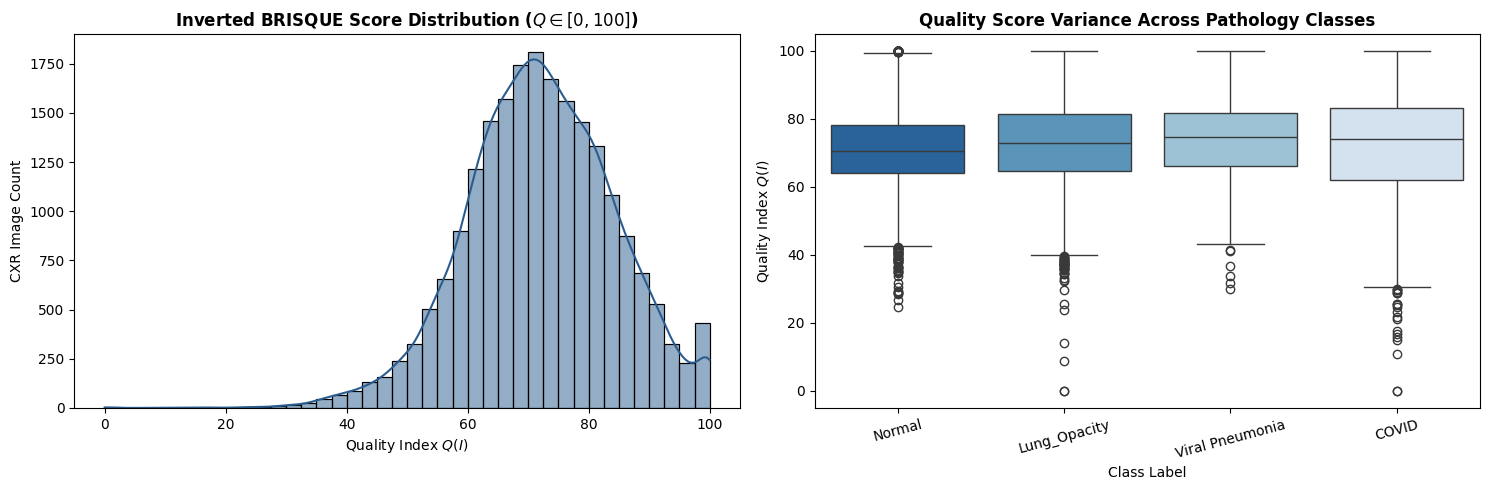


[SUCCESS] Phase 2 Execution Complete!


In [14]:
def main():
    print("==================================================================")
    print(" STARTING QAAP PIPELINE EXECUTION (PHASE 2)")
    print("==================================================================")

    # 1. Discover data
    df_raw = discover_cxr_images(Config.INPUT_DATASET_DIR)
    if len(df_raw) == 0:
        return

    # 2. Compute GPU BRISQUE Scores
    evaluator = CXRQualityEvaluator(device=Config.DEVICE, batch_size=Config.BATCH_SIZE_IQA)
    df_scores = evaluator.compute_dataset_quality(df_raw['file_path'].tolist())
    df_full = df_raw.merge(df_scores, on='file_path')

    # 3. Bin into 5 Quantile Tiers
    df_annotated = evaluator.fit_and_assign_bins(df_full)
    df_annotated.to_csv(os.path.join(Config.METRICS_DIR, 'cxr_quality_scores.csv'), index=False)

    # 4. Parameter Grid Search Optimization
    top_references = df_annotated.sort_values(by='quality_score', ascending=False)['file_path'].head(100).tolist()
    optimizer = QAAPOptimizer()
    lookup_table, df_lut = optimizer.optimize_lookup_table(top_references)

    # 5. Apply QAAP Across Full Dataset
    execute_qaap_dataset_generation(df_annotated, lookup_table, Config.OUTPUT_PREPROCESSED_DIR)

    # 6. Generate Diagnostic Visualizations
    generate_audit_visualizations(df_annotated, lookup_table)
    print("\n[SUCCESS] Phase 2 Execution Complete!")

main()

In [15]:
import os
import cv2
import time
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class Phase3Config:
    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = os.cpu_count() or 4
    BATCH_SIZE = 32
    NUM_EPOCHS = 8
    LEARNING_RATE = 1e-3
    TARGET_SIZE = (224, 224)
    MARGIN_PAD_RATIO = 0.05  # 5% anatomical context padding around lungs

    # Input candidates (Auto-detects from local Phase 2 run or attached dataset)
    QAAP_CANDIDATES = [
        '/kaggle/working/qaap_pipeline/qaap_processed_images',
        '/kaggle/input/qaap-preprocessed-cxr/qaap_processed_images',
        '/kaggle/input/qaap-preprocessed-cxr'
    ]
    QAAP_INPUT_DIR = next((p for p in QAAP_CANDIDATES if os.path.exists(p)), QAAP_CANDIDATES[0])

    # Output directories
    WORKING_DIR = '/kaggle/working/phase3_segmentation'
    OUTPUT_SEGMENTED_DIR = os.path.join(WORKING_DIR, 'segmented_lung_images')
    MODELS_DIR = os.path.join(WORKING_DIR, 'models')
    METRICS_DIR = os.path.join(WORKING_DIR, 'metrics')

for d in [Phase3Config.WORKING_DIR, Phase3Config.OUTPUT_SEGMENTED_DIR,
          Phase3Config.MODELS_DIR, Phase3Config.METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"[PHASE 3 INIT] Device: {Phase3Config.DEVICE} | QAAP Source: {Phase3Config.QAAP_INPUT_DIR}")

[PHASE 3 INIT] Device: cuda | QAAP Source: /kaggle/working/qaap_pipeline/qaap_processed_images


In [22]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder (Downsampling)
        curr_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(curr_in, feature))
            curr_in = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder (Upsampling)
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        # Final Classifier (Returns raw logits for numerical stability with AMP)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)  # Returns logits


class DiceBCEWithLogitsLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        # Sigmoid for dice computation
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        intersection = (probs_flat * targets_flat).sum()
        dice_loss = 1.0 - ((2.0 * intersection + self.smooth) /
                           (probs_flat.sum() + targets_flat.sum() + self.smooth))

        return 0.5 * bce_loss + 0.5 * dice_loss

In [17]:
# Cell 10: Mask Discovery & Dataset Builder
def discover_mask_pairs(raw_root, qaap_root):
    """
    Pairs QAAP preprocessed images with ground-truth masks from the raw dataset.
    """
    qaap_imgs = glob.glob(os.path.join(qaap_root, '**', '*.png'), recursive=True)
    if not qaap_imgs:
        qaap_imgs = glob.glob(os.path.join(qaap_root, '**', '*.jpg'), recursive=True)

    print(f"[PAIRING] Discovered {len(qaap_imgs)} QAAP processed images.")

    # Build fast mask lookup table
    raw_masks = {}
    for root, _, files in os.walk(raw_root):
        if 'mask' in root.lower():
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    raw_masks[f.lower()] = os.path.join(root, f)

    paired_records = []
    for q_path in qaap_imgs:
        f_name = os.path.basename(q_path).lower()
        # In COVID-19 dataset, mask matches image filename or has 'mask' in name
        mask_path = raw_masks.get(f_name, None)

        paired_records.append({
            'qaap_path': q_path,
            'mask_path': mask_path,
            'class': os.path.basename(os.path.dirname(q_path)),
            'file_name': os.path.basename(q_path)
        })

    df = pd.DataFrame(paired_records)
    has_mask_count = df['mask_path'].notnull().sum()
    print(f"[PAIRING] {has_mask_count}/{len(df)} images successfully paired with ground-truth masks.")
    return df


class SegmentationDataset(Dataset):
    def __init__(self, df, target_size=Phase3Config.TARGET_SIZE, is_train=True):
        self.df = df.reset_index(drop=True)
        self.target_size = target_size
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load QAAP Image (3 channels)
        img = cv2.imread(row['qaap_path'], cv2.IMREAD_COLOR)
        if img is None:
            img = np.zeros((*self.target_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if img.shape[:2] != self.target_size:
                img = cv2.resize(img, self.target_size)

        # Load Mask (1 channel)
        if pd.notnull(row['mask_path']) and os.path.exists(row['mask_path']):
            mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
            if mask is None:
                mask = np.zeros(self.target_size, dtype=np.uint8)
            else:
                if mask.shape[:2] != self.target_size:
                    mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
        else:
            mask = np.zeros(self.target_size, dtype=np.uint8)

        # Normalization
        img_tensor = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0
        mask_tensor = (torch.from_numpy(mask).float().unsqueeze(0) > 127).float()

        return img_tensor, mask_tensor

In [23]:
# Cell 11: U-Net Training Loop with Mixed Precision
def train_unet_segmentor(df_train, df_val):
    train_ds = SegmentationDataset(df_train, is_train=True)
    val_ds = SegmentationDataset(df_val, is_train=False)

    train_loader = DataLoader(
        train_ds, batch_size=Phase3Config.BATCH_SIZE, shuffle=True,
        num_workers=Phase3Config.NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=Phase3Config.BATCH_SIZE, shuffle=False,
        num_workers=Phase3Config.NUM_WORKERS, pin_memory=True
    )

    model = UNet(in_channels=3, out_channels=1).to(Phase3Config.DEVICE)
    criterion = DiceBCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=Phase3Config.LEARNING_RATE, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler()

    best_val_dice = 0.0
    best_model_path = os.path.join(Phase3Config.MODELS_DIR, 'unet_lung_best.pth')

    print("\n=======================================================")
    print(" TRAINING U-NET LUNG FIELD SEGMENTATION MODEL")
    print("=======================================================")

    for epoch in range(Phase3Config.NUM_EPOCHS):
        model.train()
        train_loss, train_dice = 0.0, 0.0

        for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{Phase3Config.NUM_EPOCHS} [Train]"):
            imgs = imgs.to(Phase3Config.DEVICE, non_blocking=True)
            masks = masks.to(Phase3Config.DEVICE, non_blocking=True)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                logits = model(imgs)
                loss = criterion(logits, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * imgs.size(0)

            # Binary Dice metric calculation
            preds_bin = (torch.sigmoid(logits) > 0.5).float()
            dice = (2.0 * (preds_bin * masks).sum()) / (preds_bin.sum() + masks.sum() + 1e-7)
            train_dice += dice.item() * imgs.size(0)

        train_loss /= len(train_ds)
        train_dice /= len(train_ds)

        # Validation
        model.eval()
        val_loss, val_dice = 0.0, 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(Phase3Config.DEVICE, non_blocking=True)
                masks = masks.to(Phase3Config.DEVICE, non_blocking=True)

                with torch.cuda.amp.autocast():
                    logits = model(imgs)
                    loss = criterion(logits, masks)

                val_loss += loss.item() * imgs.size(0)
                preds_bin = (torch.sigmoid(logits) > 0.5).float()
                dice = (2.0 * (preds_bin * masks).sum()) / (preds_bin.sum() + masks.sum() + 1e-7)
                val_dice += dice.item() * imgs.size(0)

        val_loss /= len(val_ds)
        val_dice /= len(val_ds)

        print(f"Epoch [{epoch+1:02d}/{Phase3Config.NUM_EPOCHS:02d}] "
              f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), best_model_path)
            print(f"  --> Saved Best U-Net Model (Val Dice: {val_dice:.4f})")

    print(f"\n[MODEL] Best U-Net Validation Dice: {best_val_dice:.4f}")
    return best_model_path

In [24]:
# Cell 12: High-Speed Batch Segmentation & ROI Cropping
def crop_lung_roi(img_rgb, binary_mask, pad_ratio=0.05):
    """
    Extracts the bounding box enclosing both lungs with padding and resizes to 224x224.
    """
    h, w = binary_mask.shape
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return cv2.resize(img_rgb, Phase3Config.TARGET_SIZE)

    # Filter out tiny spurious noisy contours
    min_area = 0.01 * (h * w)
    valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

    if not valid_contours:
        valid_contours = contours

    all_points = np.vstack(valid_contours)
    x, y, bw, bh = cv2.boundingRect(all_points)

    # Contextual padding
    pad_x = int(bw * pad_ratio)
    pad_y = int(bh * pad_ratio)

    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(w, x + bw + pad_x)
    y2 = min(h, y + bh + pad_y)

    cropped = img_rgb[y1:y2, x1:x2]
    return cv2.resize(cropped, Phase3Config.TARGET_SIZE, interpolation=cv2.INTER_AREA)


def generate_segmented_dataset(df_all, model_path):
    print(f"\n[INFERENCE] Segmenting and ROI cropping {len(df_all)} images...")

    model = UNet(in_channels=3, out_channels=1).to(Phase3Config.DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=Phase3Config.DEVICE))
    model.eval()

    dataset = SegmentationDataset(df_all, is_train=False)
    loader = DataLoader(
        dataset, batch_size=Phase3Config.BATCH_SIZE * 2, shuffle=False,
        num_workers=Phase3Config.NUM_WORKERS, pin_memory=True
    )

    all_indices = 0
    start_time = time.time()
    sample_visuals = []

    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="U-Net Segmentation & ROI Crop"):
            imgs_cuda = imgs.to(Phase3Config.DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                logits = model(imgs_cuda)
                pred_masks = torch.sigmoid(logits)

            pred_masks_np = (pred_masks.cpu().numpy() > 0.5).astype(np.uint8)[:, 0, :, :]
            imgs_np = (imgs.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)

            for i in range(len(imgs_np)):
                row = df_all.iloc[all_indices]
                out_path = os.path.join(
                    Phase3Config.OUTPUT_SEGMENTED_DIR, row['class'], row['file_name']
                )
                os.makedirs(os.path.dirname(out_path), exist_ok=True)

                raw_rgb = imgs_np[i]
                mask = pred_masks_np[i] * 255

                # Morphological closing to clean up rib intersections
                kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
                cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

                cropped_lung = crop_lung_roi(raw_rgb, cleaned_mask, pad_ratio=Phase3Config.MARGIN_PAD_RATIO)

                cv2.imwrite(out_path, cv2.cvtColor(cropped_lung, cv2.COLOR_RGB2BGR))

                if len(sample_visuals) < 5 and all_indices % (len(df_all) // 5 + 1) == 0:
                    sample_visuals.append((raw_rgb, cleaned_mask, cropped_lung, row['class']))

                all_indices += 1

    elapsed = time.time() - start_time
    rate = all_indices / max(elapsed, 1e-3)
    print(f"[INFERENCE] Segmented {all_indices} images in {elapsed:.2f}s ({rate:.1f} img/sec)")
    return sample_visuals

 STARTING LUNG FIELD SEGMENTATION PIPELINE (PHASE 3)
[PAIRING] Discovered 21165 QAAP processed images.
[PAIRING] 21165/21165 images successfully paired with ground-truth masks.
[DATA SPLIT] Training Masks: 16932 | Validation Masks: 4233

 TRAINING U-NET LUNG FIELD SEGMENTATION MODEL


Epoch 1/8 [Train]:   0%|          | 0/530 [00:00<?, ?it/s]

Epoch [01/08] Train Loss: 0.1178 | Train Dice: 0.9503 | Val Loss: 0.0537 | Val Dice: 0.9630
  --> Saved Best U-Net Model (Val Dice: 0.9630)


Epoch 2/8 [Train]:   0%|          | 0/530 [00:00<?, ?it/s]

Epoch [02/08] Train Loss: 0.0322 | Train Dice: 0.9761 | Val Loss: 0.0346 | Val Dice: 0.9734
  --> Saved Best U-Net Model (Val Dice: 0.9734)


...

Epoch [07/08] Train Loss: 0.0186 | Train Dice: 0.9847 | Val Loss: 0.0230 | Val Dice: 0.9812


Epoch 8/8 [Train]:   0%|          | 0/530 [00:00<?, ?it/s]

Epoch [08/08] Train Loss: 0.0183 | Train Dice: 0.9850 | Val Loss: 0.0227 | Val Dice: 0.9815
  --> Saved Best U-Net Model (Val Dice: 0.9815)

[MODEL] Best U-Net Validation Dice: 0.9815

[INFERENCE] Segmenting and ROI cropping 21165 images...


U-Net Segmentation & ROI Crop:   0%|          | 0/331 [00:00<?, ?it/s]

[INFERENCE] Segmented 21165 images in 128.09s (165.2 img/sec)


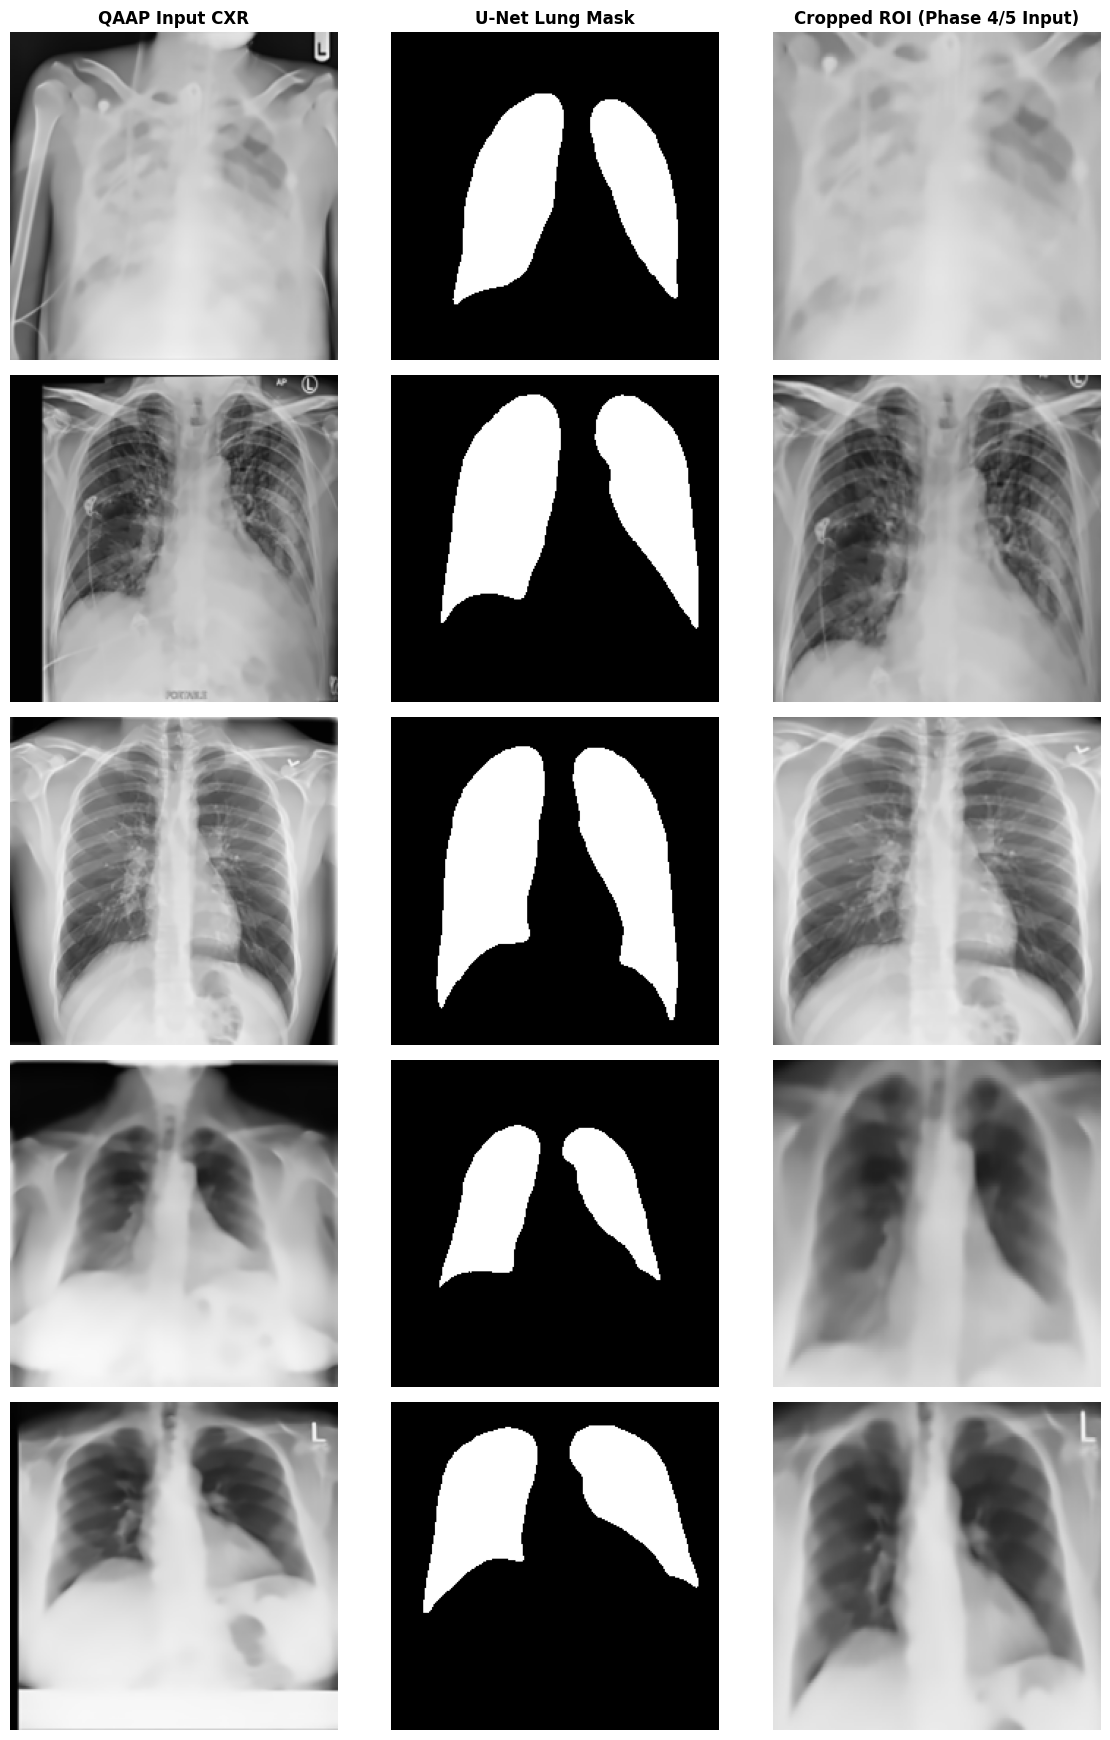


[SUCCESS] Phase 3 Lung Segmentation Complete!


In [25]:
def main_phase3():
    print("==================================================================")
    print(" STARTING LUNG FIELD SEGMENTATION PIPELINE (PHASE 3)")
    print("==================================================================")

    # 1. Discover pairs
    raw_root = Config.INPUT_DATASET_DIR
    qaap_root = Phase3Config.QAAP_INPUT_DIR
    df_all = discover_mask_pairs(raw_root, qaap_root)

    # 2. Filter images with masks for training/validation
    df_with_masks = df_all[df_all['mask_path'].notnull()].copy()

    # Train on a stratified subset (fast convergence in ~2 mins)
    df_train, df_val = train_test_split(
        df_with_masks, test_size=0.2, random_state=Phase3Config.SEED,
        stratify=df_with_masks['class']
    )
    print(f"[DATA SPLIT] Training Masks: {len(df_train)} | Validation Masks: {len(df_val)}")

    # 3. Train U-Net
    best_model_path = train_unet_segmentor(df_train, df_val)

    # 4. Generate ROI Segmented Dataset
    samples = generate_segmented_dataset(df_all, best_model_path)

    # 5. Visual Inspection Plot
    fig, axes = plt.subplots(len(samples), 3, figsize=(12, 3.5 * len(samples)))
    if len(samples) == 1:
        axes = np.expand_dims(axes, 0)

    col_titles = ["QAAP Input CXR", "U-Net Lung Mask", "Cropped ROI (Phase 4/5 Input)"]
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=12, fontweight='bold')

    for i, (orig, mask, cropped, cls_name) in enumerate(samples):
        axes[i, 0].imshow(orig)
        axes[i, 0].set_ylabel(cls_name, fontsize=11, fontweight='bold')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(cropped)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(Phase3Config.METRICS_DIR, 'unet_segmentation_samples.png'), dpi=300)
    plt.show()

    print("\n[SUCCESS] Phase 3 Lung Segmentation Complete!")

main_phase3()

In [48]:
# Cell 13.5: Full GPU & IPython Memory Purge
import gc
import sys
import torch

# Clear Jupyter/IPython internal output history
if 'IPython' in sys.modules:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic('reset_selective', '-f ^(unet|model|ssl_model|optimizer|scaler|img_batch|mask_batch|probs|loss)')
        if hasattr(ip, 'user_ns'):
            for key in list(ip.user_ns.keys()):
                if key.startswith('_') or key in ['Out', 'In']:
                    continue

# Clear GPU cache
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# Report available memory
free_vram = torch.cuda.mem_get_info()[0] / (1024**3)
total_vram = torch.cuda.mem_get_info()[1] / (1024**3)
print(f"[VRAM RECLAIMED] Free GPU Memory: {free_vram:.2f} GB / {total_vram:.2f} GB")

[VRAM RECLAIMED] Free GPU Memory: 0.10 GB / 14.56 GB


In [6]:
import os
import glob
import gc
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

# Clear any lingering GPU cache
gc.collect()
torch.cuda.empty_cache()

class Phase4Config:
    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = 2
    BATCH_SIZE = 32           # Safe for 15GB T4 VRAM with ConvNeXt-Small
    EPOCHS = 15               # Number of SSL pretraining epochs
    LEARNING_RATE = 3e-4
    WEIGHT_DECAY = 1e-4
    TEMPERATURE = 0.07        # NT-Xent temperature scaling
    EMBEDDING_DIM = 128       # Projection head output dimension
    TARGET_SIZE = (224, 224)
    BACKBONE = 'convnext_small'

    # Dataset search root
    DATA_ROOT = '/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset'
    WORKING_DIR = '/kaggle/working/phase4_ssl'
    MODELS_DIR = os.path.join(WORKING_DIR, 'models')
    METRICS_DIR = os.path.join(WORKING_DIR, 'metrics')

# Ensure output directories exist
os.makedirs(Phase4Config.MODELS_DIR, exist_ok=True)
os.makedirs(Phase4Config.METRICS_DIR, exist_ok=True)

# Set deterministic seeds
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(Phase4Config.SEED)

# Discover all image paths across all categories
all_image_paths = sorted(glob.glob(os.path.join(Phase4Config.DATA_ROOT, '*/images/*.png')))
print(f"[Phase 4] Discovered {len(all_image_paths)} total CXR images for Self-Supervised Pretraining.")
print(f"[Phase 4] Target Device: {Phase4Config.DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

[Phase 4] Discovered 21165 total CXR images for Self-Supervised Pretraining.
[Phase 4] Target Device: cuda (Tesla T4)


In [7]:
class SimCLRTransform:
    """Generates two distinct stochastic augmented views (x_i, x_j) of an input image."""
    def __init__(self, size=(224, 224)):
        self.transform = T.Compose([
            T.RandomResizedCrop(size=size, scale=(0.75, 1.0), ratio=(0.85, 1.15)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __call__(self, x):
        return self.transform(x), self.transform(x)


class UnlabeledCXRDataset(Dataset):
    """Dataset for self-supervised contrastive learning (no class labels required)."""
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            view1, view2 = self.transform(img)
            return view1, view2
        tensor_img = T.ToTensor()(img)
        return tensor_img, tensor_img


class SimCLRModel(nn.Module):
    """
    SimCLR Architecture:
      - Encoder Backbone: ConvNeXt-Small (feature representation h in R^D)
      - Projection Head: 2-layer MLP with BatchNorm and ReLU (projection z in R^128)
    """
    def __init__(self, backbone_name='convnext_small', projection_dim=128, pretrained=True):
        super().__init__()
        # Backbone feature extractor (num_classes=0 returns pool feature vector)
        self.encoder = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        in_features = self.encoder.num_features

        # Non-linear 2-layer MLP projection head
        self.projector = nn.Sequential(
            nn.Linear(in_features, in_features),
            nn.BatchNorm1d(in_features),
            nn.ReLU(inplace=True),
            nn.Linear(in_features, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = F.normalize(self.projector(h), dim=1)
        return h, z

# Initialize Dataset and DataLoader
ssl_dataset = UnlabeledCXRDataset(all_image_paths, transform=SimCLRTransform(Phase4Config.TARGET_SIZE))
ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=Phase4Config.BATCH_SIZE,
    shuffle=True,
    num_workers=Phase4Config.NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

print(f"[Phase 4] Initialized DataLoader with {len(ssl_dataset)} samples ({len(ssl_loader)} batches per epoch).")

[Phase 4] Initialized DataLoader with 21165 samples (661 batches per epoch).


In [9]:
class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross Entropy Loss (NT-Xent).
    AMP float16 safe: similarity computation and masking are handled in float32.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        # Force float32 to prevent float16 underflow/overflow during dot product and softmax
        z_i = z_i.float()
        z_j = z_j.float()
        batch_size = z_i.size(0)

        # 2N x D representation matrix
        z = torch.cat([z_i, z_j], dim=0)

        # Cosine similarity matrix scaled by temperature: (2N, 2N)
        sim_matrix = torch.matmul(z, z.T) / self.temperature

        # Mask out self-similarities along the diagonal with safe -1e4
        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
        sim_matrix = sim_matrix.masked_fill(mask, -1e4)

        # Ground truth indices: (view1_i <-> view2_i)
        targets = (torch.arange(2 * batch_size, device=z.device) + batch_size) % (2 * batch_size)

        loss = F.cross_entropy(sim_matrix, targets)
        return loss

print("[Phase 4] NTXentLoss initialized successfully.")

[Phase 4] NTXentLoss initialized successfully.


In [10]:
import time
from tqdm.notebook import tqdm

# Initialize model, optimizer, scheduler, and AMP gradient scaler
ssl_model = SimCLRModel(
    backbone_name=Phase4Config.BACKBONE,
    projection_dim=Phase4Config.EMBEDDING_DIM,
    pretrained=True
).to(Phase4Config.DEVICE)

criterion = NTXentLoss(temperature=Phase4Config.TEMPERATURE)
optimizer = torch.optim.AdamW(
    ssl_model.parameters(),
    lr=Phase4Config.LEARNING_RATE,
    weight_decay=Phase4Config.WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=Phase4Config.EPOCHS,
    eta_min=1e-6
)
scaler = torch.cuda.amp.GradScaler()

best_loss = float('inf')
training_history = []

print(f"=== Starting SimCLR Pretraining on {len(all_image_paths)} Unlabeled CXRs ===")
print(f"Backbone: {Phase4Config.BACKBONE} | Epochs: {Phase4Config.EPOCHS} | Batch Size: {Phase4Config.BATCH_SIZE}")

for epoch in range(1, Phase4Config.EPOCHS + 1):
    ssl_model.train()
    total_loss = 0.0
    start_time = time.time()

    progress_bar = tqdm(ssl_loader, desc=f"Epoch [{epoch:02d}/{Phase4Config.EPOCHS:02d}]", leave=True)

    for step, (view1, view2) in enumerate(progress_bar):
        view1 = view1.to(Phase4Config.DEVICE, non_blocking=True)
        view2 = view2.to(Phase4Config.DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed-precision forward pass
        with torch.cuda.amp.autocast():
            _, z_i = ssl_model(view1)
            _, z_j = ssl_model(view2)
            loss = criterion(z_i, z_j)

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_loss = loss.item()
        total_loss += batch_loss
        progress_bar.set_postfix({'loss': f"{batch_loss:.4f}", 'lr': f"{scheduler.get_last_lr()[0]:.2e}"})

    epoch_loss = total_loss / len(ssl_loader)
    scheduler.step()
    elapsed = time.time() - start_time

    training_history.append({'epoch': epoch, 'loss': epoch_loss, 'lr': scheduler.get_last_lr()[0], 'time': elapsed})
    print(f"Epoch {epoch:02d}/{Phase4Config.EPOCHS:02d} Complete | Avg Loss: {epoch_loss:.4f} | Time: {elapsed:.1f}s")

    # Save best and latest checkpoints
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': ssl_model.state_dict(),
        'encoder_state_dict': ssl_model.encoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': epoch_loss,
    }

    # Save latest
    torch.save(checkpoint, os.path.join(Phase4Config.MODELS_DIR, 'simclr_convnext_latest.pth'))

    # Save best
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(checkpoint, os.path.join(Phase4Config.MODELS_DIR, 'simclr_convnext_best.pth'))
        print(f"  --> Saved new best checkpoint with loss: {best_loss:.4f}")

# Save loss trajectory to CSV
history_df = pd.DataFrame(training_history)
history_df.to_csv(os.path.join(Phase4Config.METRICS_DIR, 'simclr_training_log.csv'), index=False)
print("\n[Phase 4 Pretraining Completed] Pretrained CXR Backbone saved to:", os.path.join(Phase4Config.MODELS_DIR, 'simclr_convnext_best.pth'))

=== Starting SimCLR Pretraining on 21165 Unlabeled CXRs ===
Backbone: convnext_small | Epochs: 15 | Batch Size: 32


Epoch [01/15]:   0%|          | 0/661 [00:00<?, ?it/s]

Epoch 01/15 Complete | Avg Loss: 0.0676 | Time: 345.2s
  --> Saved new best checkpoint with loss: 0.0676


Epoch [02/15]:   0%|          | 0/661 [00:00<?, ?it/s]

Epoch 02/15 Complete | Avg Loss: 0.0015 | Time: 321.9s
  --> Saved new best checkpoint with loss: 0.0015


...

Epoch 13/15 Complete | Avg Loss: 0.0031 | Time: 324.1s


Epoch [14/15]:   0%|          | 0/661 [00:00<?, ?it/s]

Epoch 14/15 Complete | Avg Loss: 0.0029 | Time: 323.5s


Epoch [15/15]:   0%|          | 0/661 [00:00<?, ?it/s]

Epoch 15/15 Complete | Avg Loss: 0.0022 | Time: 322.9s

[Phase 4 Pretraining Completed] Pretrained CXR Backbone saved to: /kaggle/working/phase4_ssl/models/simclr_convnext_best.pth
